## Setup

In [1]:
from gut_former.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

import phate
from adjustText import adjust_text
from collections import Counter

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
from gut_former.utils.project_paths import find_data_path, find_figures_path

data_path = find_data_path()
output_path = find_data_path().parent / "output"
figures_path = find_figures_path()
figures_path.mkdir(parents=True, exist_ok=True)

In [4]:
country_to_region = {
    "DEU": "europe", "ESP": "europe", "ITA": "europe", "FRA": "europe", "NLD": "europe",
    "FIN": "europe", "EST": "europe", "LUX": "europe", "DNK": "europe", "GBR": "europe",
    "SWE": "europe", "NOR": "europe", "SVK": "europe", "HUN": "europe", "ISL": "europe",
    "AUT": "europe", "IRL": "europe", "RUS": "europe",
    "JPN": "east_asia", "CHN": "east_asia", "KOR": "east_asia", "MNG": "east_asia",
    "IND": "south_asia", "BGD": "south_asia",
    "KAZ": "central_asia", "ISR": "middle_east",
    "MDG": "africa", "TZA": "africa", "GHA": "africa", "CMR": "africa", "ETH": "africa", "LBR": "africa",
    "USA": "north_america", "CAN": "north_america",
    "PER": "south_america", "SLV": "south_america", "FJI": "oceania",
}

disease_to_group = {
    "CRC": "cancer", "adenoma": "cancer", "melanoma": "cancer", "carcinoma_surgery_history": "cancer",
    "T2D": "metabolic", "T1D": "metabolic", "IGT": "metabolic", "metabolic_syndrome": "metabolic",
    "hypertension": "cardiometabolic", "pre-hypertension": "cardiometabolic", "ACVD": "cardiometabolic",
    "fatty_liver": "metabolic", "cirrhosis": "metabolic",
    "IBD": "autoimmune", "AS": "autoimmune", "ME/CFS": "systemic", "schizophrenia": "neuropsychiatric",
    "acute_diarrhoea": "gi_infection", "CDI": "gi_infection", "STEC": "gi_infection", "STH": "gi_infection",
    "bronchitis": "infection", "respiratoryinf": "infection", "otitis": "infection",
    "PD": "neurological", "FMT": "intervention", "control": "control",
}

## Read Data

In [5]:
latent_df = pd.read_csv(f"{output_path}/latent_sample.csv", index_col=0)

metadata = (
    pd.read_csv(f"{data_path}/metadata_sample.csv", low_memory=False)
    .query("sample_id in @latent_df.index")
    .sort_index()
)
metadata["health_status"] = (metadata["study_condition"] != "control").astype(int)

health_status_dict   = dict(zip(metadata.sample_id, metadata.health_status))
study_condition_dict = dict(zip(metadata.sample_id, metadata.study_condition))
country_dict         = dict(zip(metadata.sample_id, metadata.country))
study_name_dict      = dict(zip(metadata.sample_id, metadata.study_name))
age_cat_dict         = dict(zip(metadata.sample_id, metadata.age_category))

print(f"latent: {latent_df.shape} | metadata: {metadata.shape}")

latent: (128, 64) | metadata: (128, 143)


/var/folders/6p/lf2mjrln3bn2l0f1tywc4j580000gn/T/ipykernel_24615/2437493367.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metadata["health_status"] = (metadata["study_condition"] != "control").astype(int)


## Signatures & dominant features

In [6]:
# Dominant topic per sample (taxonomic + functional signatures)
EsT = pd.read_csv(f"{data_path}/W_train_5_sample_taxonomy_all.csv", index_col=0)
EsT.columns = [f"TS{i + 1}" for i in range(EsT.shape[1])]
EsT_dict = dict(zip(EsT.index, EsT.T.idxmax().values))

EsF = pd.read_csv(f"{data_path}/W_train_8_sample_pathways_all.csv", index_col=0).loc[EsT.index]
EsF.columns = [f"FS{i + 1}" for i in range(EsF.shape[1])]
EsF_dict = dict(zip(EsF.index, EsF.T.idxmax().values))

# Dominant species / pathway per sample (from log-abundance)
Xt = pd.read_csv(f"{data_path}/taxonomy_sample.csv", index_col=0)
Xt_log = np.log(Xt + 1)
top_taxa_list = Xt_log.apply(lambda r: [t.split("|")[6] for t in r.nlargest(2).index], axis=1)
top_taxa_dict = top_taxa_list.apply(lambda x: x[0]).to_dict()

Xp = pd.read_csv(f"{data_path}/pathways_sample.csv", index_col=0)
Xp.columns = [c.split(":")[0] for c in Xp.columns]
Xp_log = np.log(Xp + 1)
top_fun_list = Xp_log.apply(lambda r: r.nlargest(2).index.tolist(), axis=1)
top_fun1_dict = top_fun_list.apply(lambda x: x[0]).to_dict()

# Figure 3A - PHATE embedding

In [7]:
def fit_phate(latent_df, n_pca=10, knn=5):
    phate_op = phate.PHATE(n_components=5, random_state=42, n_pca=n_pca, knn=knn)
    data_phate = phate_op.fit_transform(latent_df)

    col_maps = {
        "EsT":           EsT_dict,
        "EsF":           EsF_dict,
        "health_status": health_status_dict,
        "condition":     study_condition_dict,
        "top_species":   top_taxa_dict,
        "top_fun":       top_fun1_dict,
        "location":      country_dict,
        "age":           age_cat_dict,
    }
    df = (
        pd.DataFrame(data_phate, columns=[f"P{i}" for i in range(5)], index=latent_df.index)
        .assign(**{col: latent_df.index.map(mapping) for col, mapping in col_maps.items()})
        .assign(
            EsT_name=lambda d: d["EsT"],
            EsF_name=lambda d: d["EsF"],
            diseases_mapped=lambda d: d["condition"].map(disease_to_group),
            country_mapped=lambda d: d["location"].map(country_to_region),
        )
    )
    return df.sort_values(by=["EsF_name", "EsT_name"])


def plot_phate(input_df, output_file):
    fig, axes = plt.subplots(2, 3, figsize=(20, 8))
    ax = axes.flatten()
    kwargs = {"s": 10, "edgecolor": None, "alpha": 0.8}

    configs = [
        ("EsT_name",       "tab10",  "GENUS TOPIC"),
        ("EsF_name",       "Paired", "PATHWAY TOPIC"),
        ("country_mapped", "bright", "LOCATION"),
    ]
    row_pairs = [("P0", "P1"), ("P1", "P2")]

    for row, (x, y) in enumerate(row_pairs):
        for col, (hue, palette, title) in enumerate(configs):
            i = row * 3 + col
            sns.scatterplot(data=input_df, x=x, y=y, hue=hue, palette=palette,
                            legend=(row == 0), ax=ax[i], **kwargs)
            if row == 0:
                ax[i].set_title(f"{title}\n", fontsize=14, fontweight="bold")
                ax[i].legend(loc="upper left", borderaxespad=1, edgecolor="w",
                             markerscale=3, fontsize=12)
            ax[i].spines[["top", "right", "left", "bottom"]].set_visible(False)
            ax[i].grid(False)
            ax[i].set_xticks([])
            ax[i].set_yticks([])

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

Calculating PHATE...


  Running PHATE on 128 observations and 64 variables.


  Calculating graph and diffusion operator...


    Calculating PCA...


    Calculating KNN search...


...

  Calculated diffusion potential in 0.07 seconds.


  Calculating metric MDS...


    SGD-MDS may not have converged: stress changed by 3.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


  Calculated metric MDS in 0.20 seconds.


Calculated PHATE in 0.34 seconds.


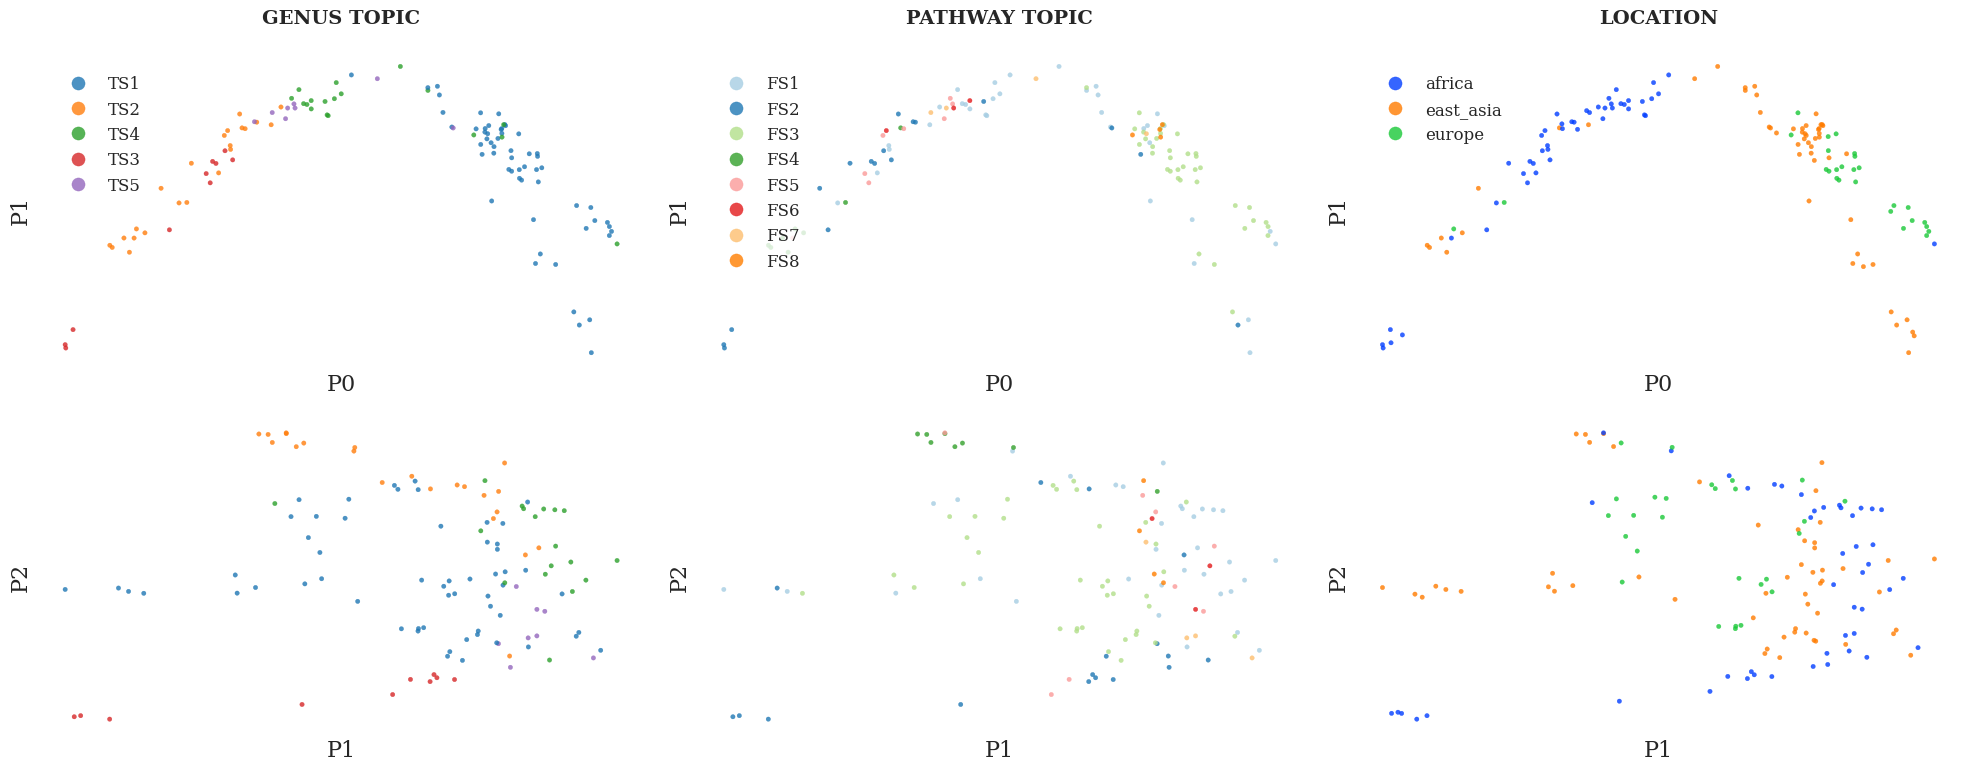

In [8]:
phate_default = fit_phate(latent_df)
phate_default["study_name"] = phate_default.index.map(study_name_dict)
plot_phate(phate_default, f"{figures_path}/Fig3A.png")

# Supplementary Figure 3A - PHATE by study

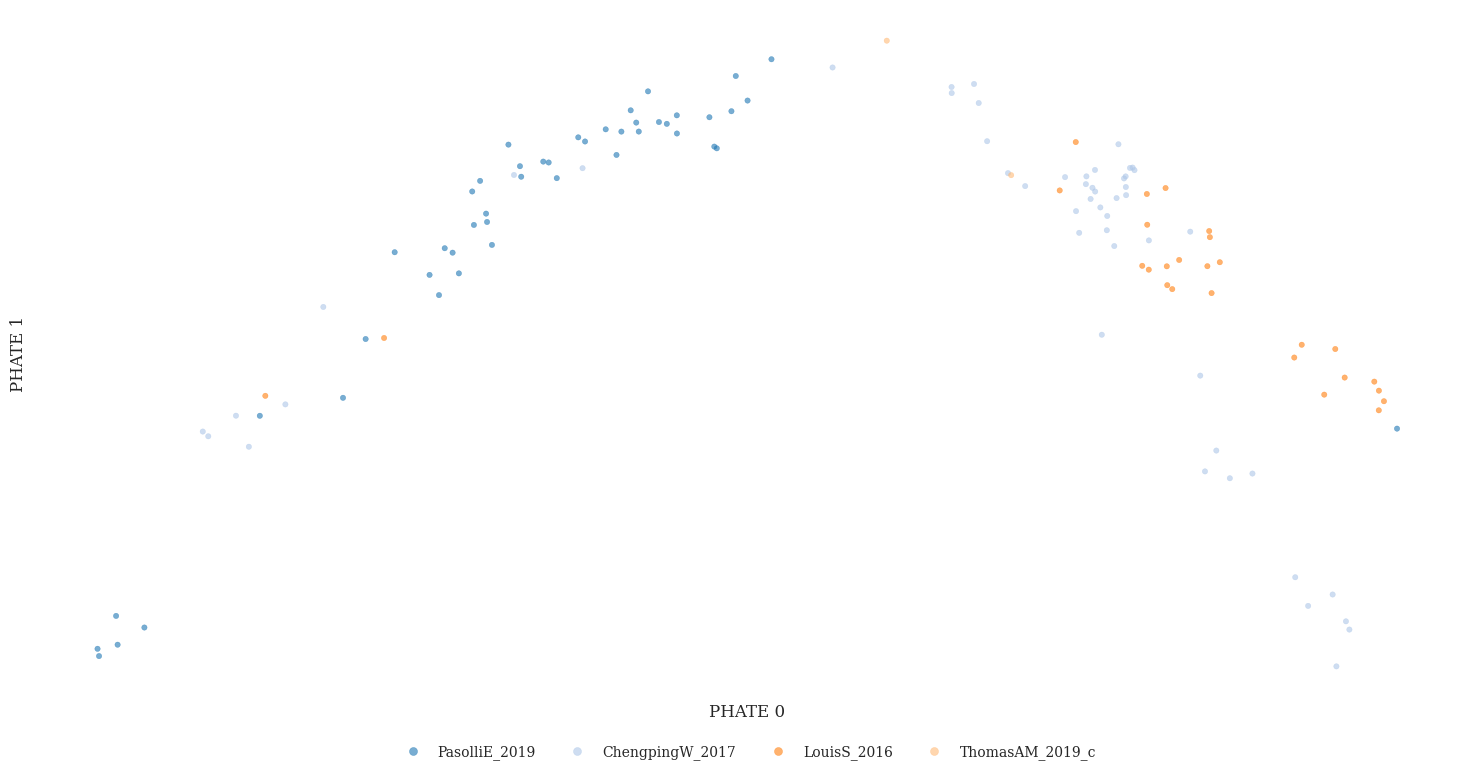

In [9]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.scatterplot(data=phate_default, x="P0", y="P1", hue="study_name",
                legend=True, edgecolor=None, alpha=0.6, s=15, ax=ax, palette="tab20")
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("PHATE 0", fontsize=12)
ax.set_ylabel("PHATE 1", fontsize=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=6,
          fontsize=10, frameon=False, markerscale=1.5)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig3A.png", dpi=300, bbox_inches="tight")
plt.show()

# Supplementary Figure 3B - PHATE by health status

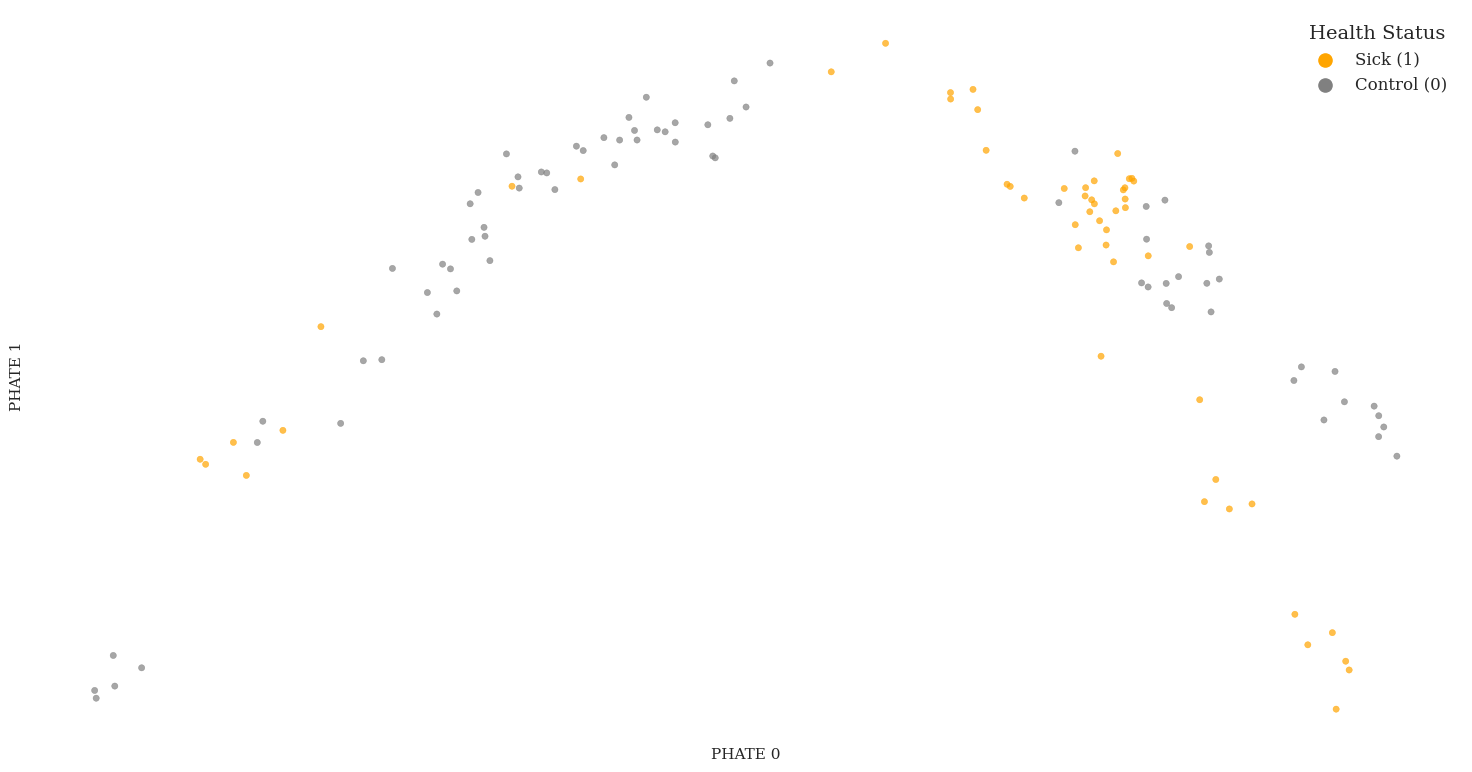

In [10]:
palette = {1: "orange", 0: "grey"}
d = phate_default  # 128 samples - no subsampling needed

fig, ax = plt.subplots(figsize=(15, 8))
sns.scatterplot(data=d, x="P0", y="P1", hue="health_status", palette=palette,
                legend=False, edgecolor=None, alpha=0.7, s=20, ax=ax)
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("PHATE 0", fontsize=11)
ax.set_ylabel("PHATE 1", fontsize=11)
handles = [plt.scatter([], [], color="orange", s=40, label="Sick (1)"),
           plt.scatter([], [], color="grey", s=40, label="Control (0)")]
ax.legend(handles=handles, title="Health Status", title_fontsize=14, fontsize=12,
          bbox_to_anchor=(1, 1), frameon=False, markerscale=1.5)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig3B.png", dpi=300, bbox_inches="tight")
plt.show()

# Supplementary Figure 3C - health status stratified by country

In [11]:
def plot_country_health_status(df_in, px, py, output_plot):
    SEED = 42
    palette = {1: "orange", 0: "grey"}

    counts = df_in["location"].value_counts().head(30).index
    countries = [c for c in counts
                 if df_in.query("location == @c")["health_status"].nunique() == 2]

    if not countries:
        print("No country has both health statuses on this dataset - skipping sFig3C.")
        return

    n_cols = min(5, len(countries))
    n_rows = (len(countries) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3), squeeze=False)
    axes = axes.flatten()

    for i, location in enumerate(countries):
        ax = axes[i]
        d = df_in.query("location == @location")
        sick = d[d["health_status"] == 1]
        control = d[d["health_status"] == 0]
        n = min(len(sick), len(control), 70)
        sick = sick.sample(n, random_state=SEED)
        control = control.sample(n, random_state=SEED)
        d = pd.concat([sick, control])
        sns.scatterplot(data=d, x=px, y=py, hue="health_status", legend=False,
                        edgecolor=None, alpha=0.7, s=20, ax=ax, palette=palette)
        ax.set_title(f"{location}", fontsize=11, fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.grid(linestyle=":", lw=0.6, alpha=0.6)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        ax.set_xticks([]); ax.set_yticks([])

    for i in range(len(countries), len(axes)):
        axes[i].set_visible(False)

    fig.text(0.5, 0, px, ha="center", weight="bold", fontsize=12)
    fig.text(0, 0.5, py, ha="center", weight="bold", fontsize=12, rotation="vertical")
    plt.tight_layout()
    plt.savefig(output_plot, dpi=300, bbox_inches="tight")
    plt.show()


plot_country_health_status(phate_default, px="P2", py="P3",
                           output_plot=f"{figures_path}/sFig3C.png")

No country has both health statuses on this dataset - skipping sFig3C.


# Supplementary Figure 3D/E - dominant species

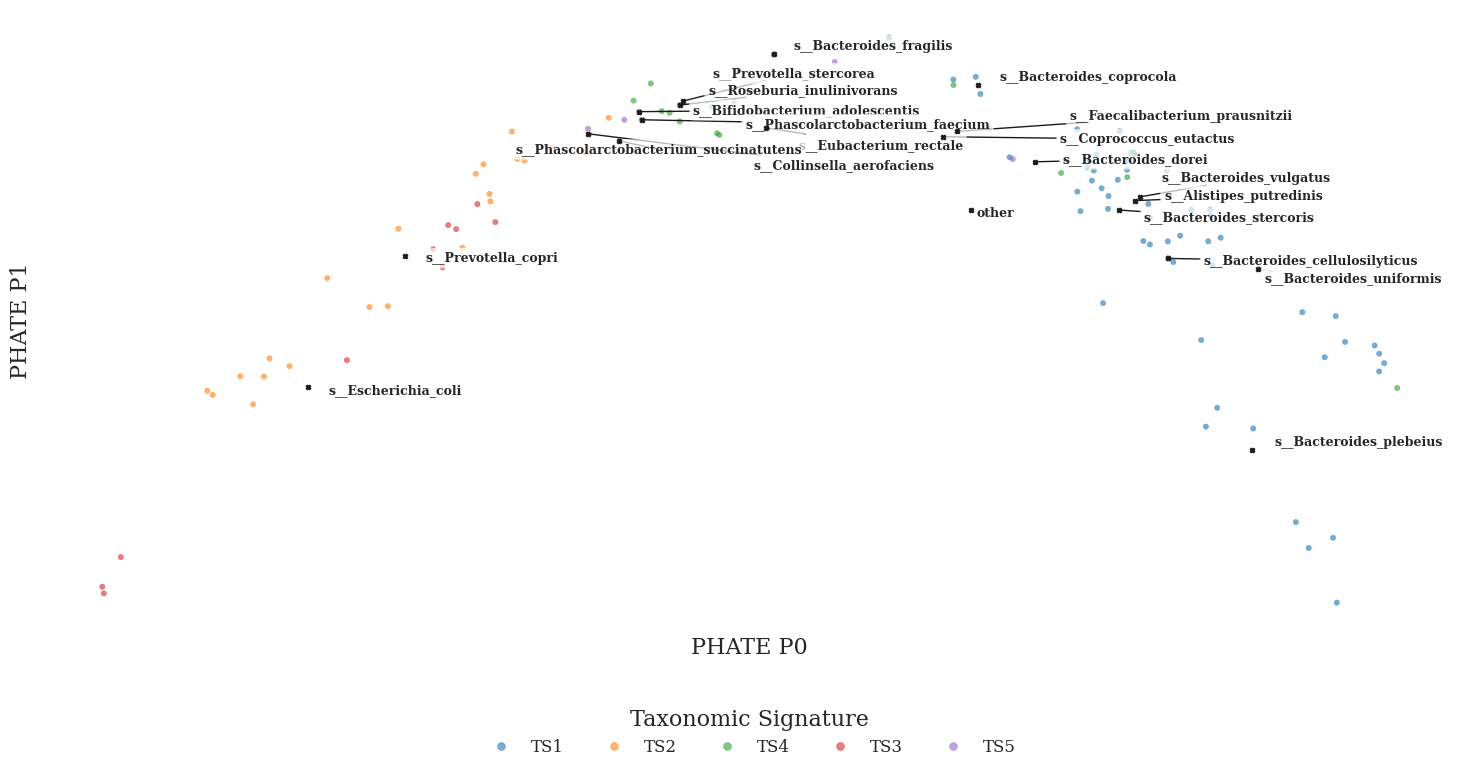

In [12]:
top_counter = (pd.DataFrame.from_dict(Counter(phate_default["top_species"]), orient="index")
               .sort_values(by=[0], ascending=False))
top_counter["keep"] = np.where(top_counter.index.isin(top_counter.head(20).index),
                               top_counter.index, "other")
phate_default["top_species_fltr"] = phate_default["top_species"].map(dict(zip(top_counter.index, top_counter["keep"])))

fig, ax = plt.subplots(figsize=(15, 8))
sns.scatterplot(data=phate_default, x="P0", y="P1", hue="EsT_name",
                legend=True, edgecolor=None, alpha=0.6, s=15, ax=ax, palette="tab10")
centroids = phate_default.groupby("top_species_fltr")[["P0", "P1"]].mean()
texts = []
for name, row in centroids.iterrows():
    ax.scatter(row["P0"], row["P1"], s=10, color="k", zorder=5, marker="X")
    texts.append(ax.text(row["P0"], row["P1"], name, fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.7)))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="k", lw=1))
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("PHATE P0", fontsize=16); ax.set_ylabel("PHATE P1", fontsize=16)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=6, fontsize=12,
          frameon=False, markerscale=1.5, title="Taxonomic Signature", title_fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig3D.png", dpi=300, bbox_inches="tight")
plt.show()

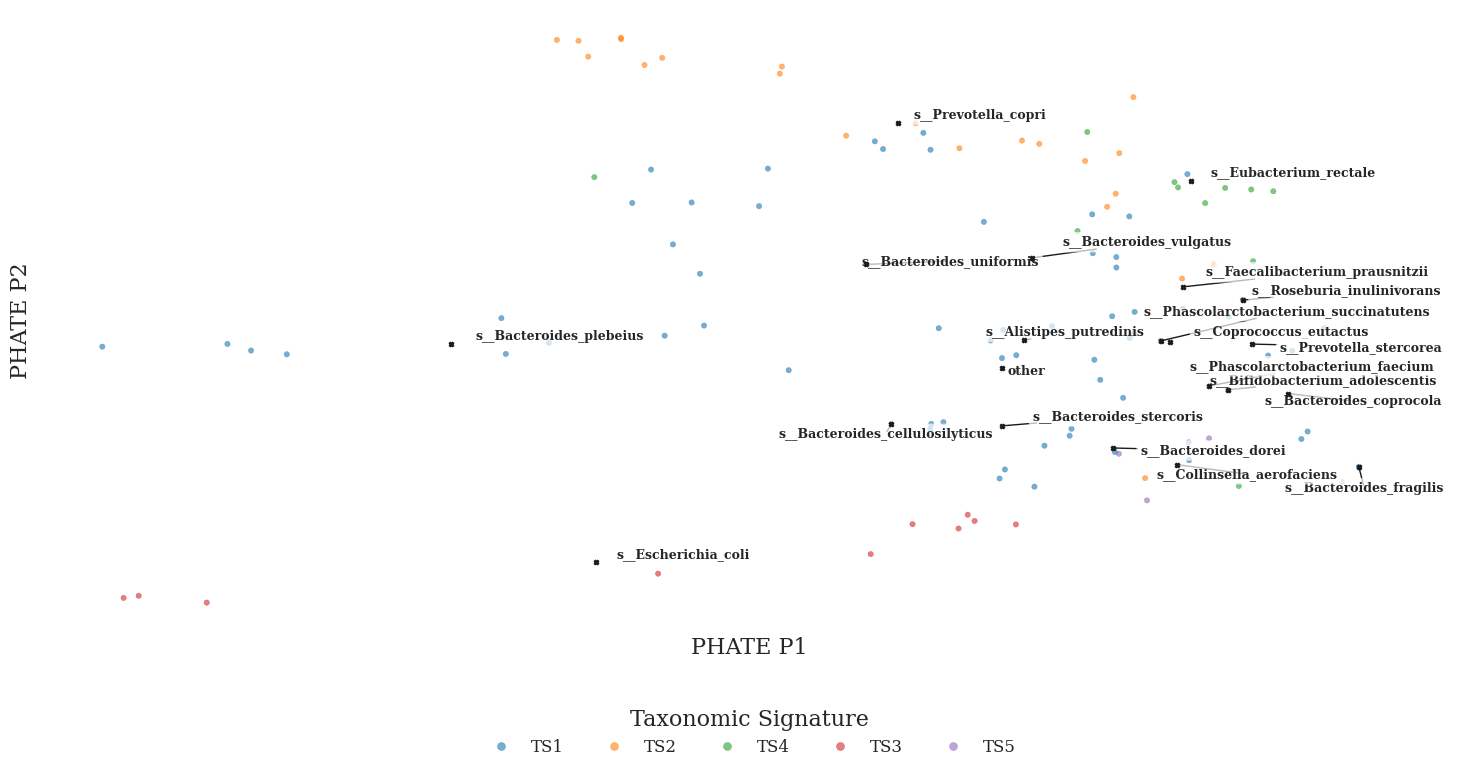

In [13]:
top_counter = (pd.DataFrame.from_dict(Counter(phate_default["top_species"]), orient="index")
               .sort_values(by=[0], ascending=False))
top_counter["keep"] = np.where(top_counter.index.isin(top_counter.head(20).index),
                               top_counter.index, "other")
phate_default["top_species_fltr"] = phate_default["top_species"].map(dict(zip(top_counter.index, top_counter["keep"])))

fig, ax = plt.subplots(figsize=(15, 8))
sns.scatterplot(data=phate_default, x="P1", y="P2", hue="EsT_name",
                legend=True, edgecolor=None, alpha=0.6, s=15, ax=ax, palette="tab10")
centroids = phate_default.groupby("top_species_fltr")[["P1", "P2"]].mean()
texts = []
for name, row in centroids.iterrows():
    ax.scatter(row["P1"], row["P2"], s=10, color="k", zorder=5, marker="X")
    texts.append(ax.text(row["P1"], row["P2"], name, fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.7)))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="k", lw=1))
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("PHATE P1", fontsize=16); ax.set_ylabel("PHATE P2", fontsize=16)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=6, fontsize=12,
          frameon=False, markerscale=1.5, title="Taxonomic Signature", title_fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig3E.png", dpi=300, bbox_inches="tight")
plt.show()

# Supplementary Figure 3F/G - dominant pathways

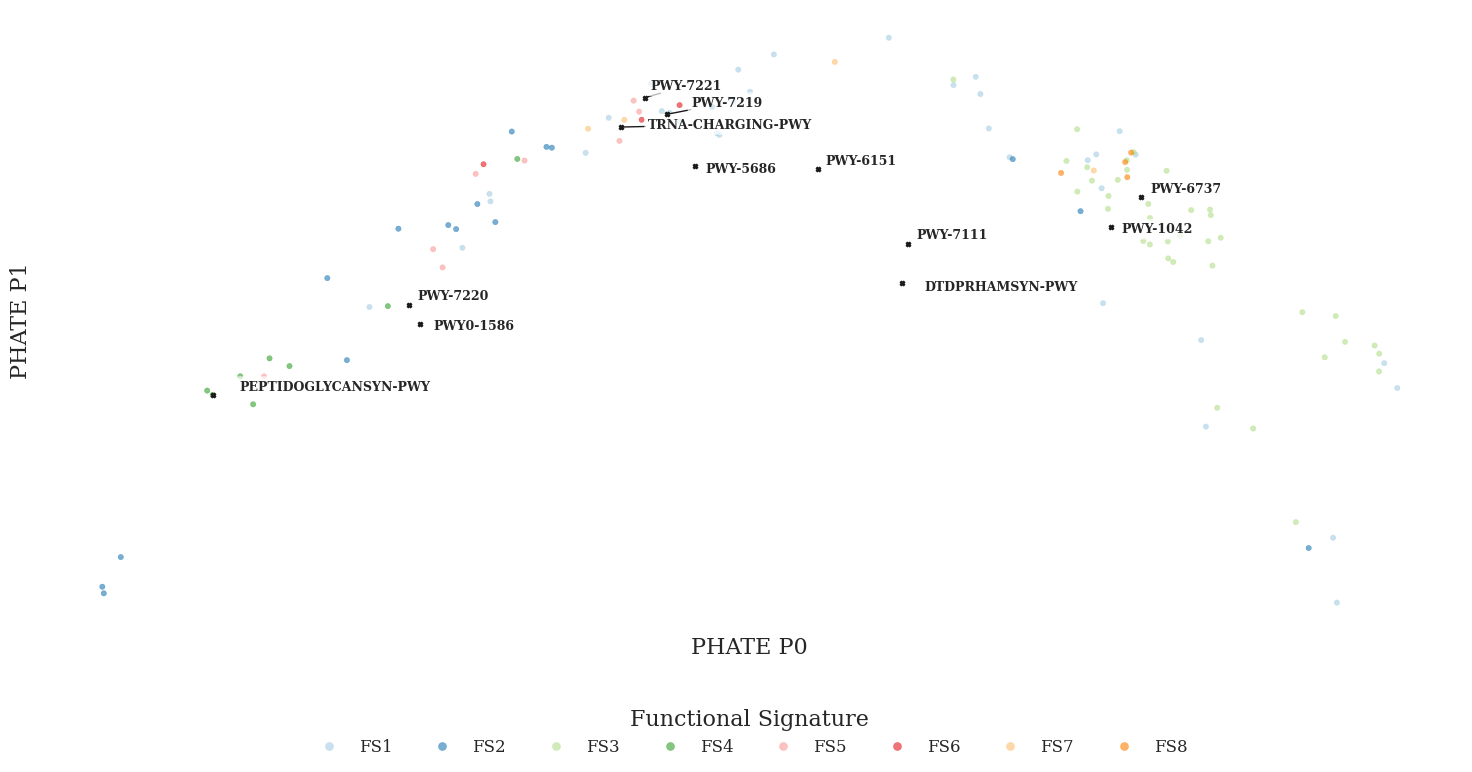

In [14]:
top_counter = (pd.DataFrame.from_dict(Counter(phate_default["top_fun"]), orient="index")
               .sort_values(by=[0], ascending=False))
top_counter["keep"] = np.where(top_counter.index.isin(top_counter.head(50).index),
                               top_counter.index, "other")
phate_default["top_fun_fltr"] = phate_default["top_fun"].map(dict(zip(top_counter.index, top_counter["keep"])))

fig, ax = plt.subplots(figsize=(15, 8))
sns.scatterplot(data=phate_default, x="P0", y="P1", hue="EsF_name",
                legend=True, edgecolor=None, alpha=0.6, s=15, ax=ax, palette="Paired")
centroids = phate_default.groupby("top_fun_fltr")[["P0", "P1"]].mean()
texts = []
for name, row in centroids.iterrows():
    ax.scatter(row["P0"], row["P1"], s=10, color="k", zorder=5, marker="X")
    texts.append(ax.text(row["P0"], row["P1"], name, fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.7)))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="k", lw=1))
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("PHATE P0", fontsize=16); ax.set_ylabel("PHATE P1", fontsize=16)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=8, fontsize=12,
          frameon=False, markerscale=1.5, title="Functional Signature", title_fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig3F.png", dpi=300, bbox_inches="tight")
plt.show()

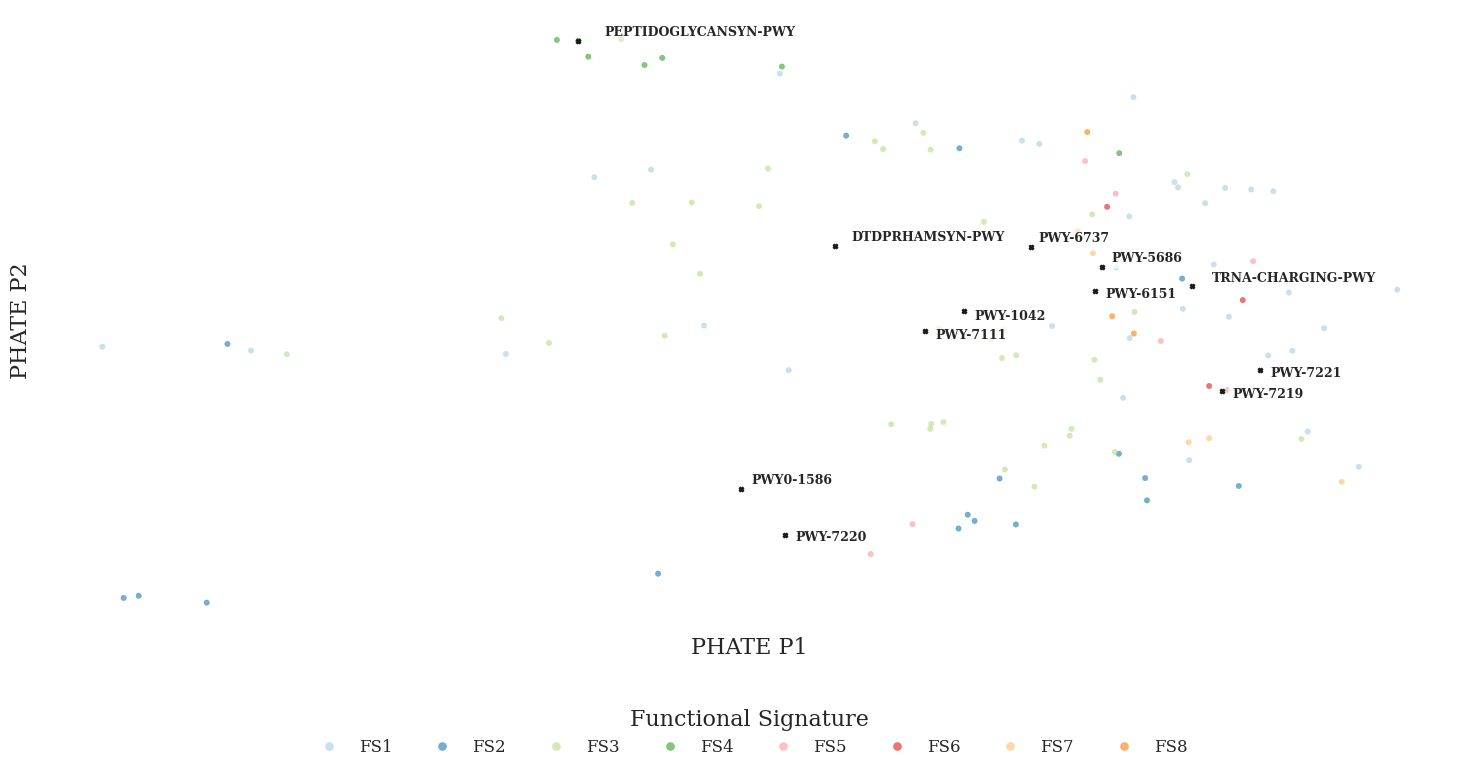

In [15]:
top_counter = (pd.DataFrame.from_dict(Counter(phate_default["top_fun"]), orient="index")
               .sort_values(by=[0], ascending=False))
top_counter["keep"] = np.where(top_counter.index.isin(top_counter.head(50).index),
                               top_counter.index, "other")
phate_default["top_fun_fltr"] = phate_default["top_fun"].map(dict(zip(top_counter.index, top_counter["keep"])))

fig, ax = plt.subplots(figsize=(15, 8))
sns.scatterplot(data=phate_default, x="P1", y="P2", hue="EsF_name",
                legend=True, edgecolor=None, alpha=0.6, s=15, ax=ax, palette="Paired")
centroids = phate_default.groupby("top_fun_fltr")[["P1", "P2"]].mean()
texts = []
for name, row in centroids.iterrows():
    ax.scatter(row["P1"], row["P2"], s=10, color="k", zorder=5, marker="X")
    texts.append(ax.text(row["P1"], row["P2"], name, fontsize=9, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.7)))
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="k", lw=1))
ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
ax.set_xlabel("PHATE P1", fontsize=16); ax.set_ylabel("PHATE P2", fontsize=16)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=8, fontsize=12,
          frameon=False, markerscale=1.5, title="Functional Signature", title_fontsize=16)
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(f"{figures_path}/sFig3G.png", dpi=300, bbox_inches="tight")
plt.show()